In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [2]:
a = 2
avg_len = 0.08
radius = 0.8

In [6]:
angle = 90
r = 2.5

In [9]:

h = 5
dash_point = np.array([np.cos(angle / 180 * np.pi), np.sin(angle / 180 * np.pi)]) * r + np.array([0, 0])
m, marker = pattern_generator_using_gmsh.get_single_dash(h, avg_len, avg_len, dash_point = dash_point)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)


In [12]:

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

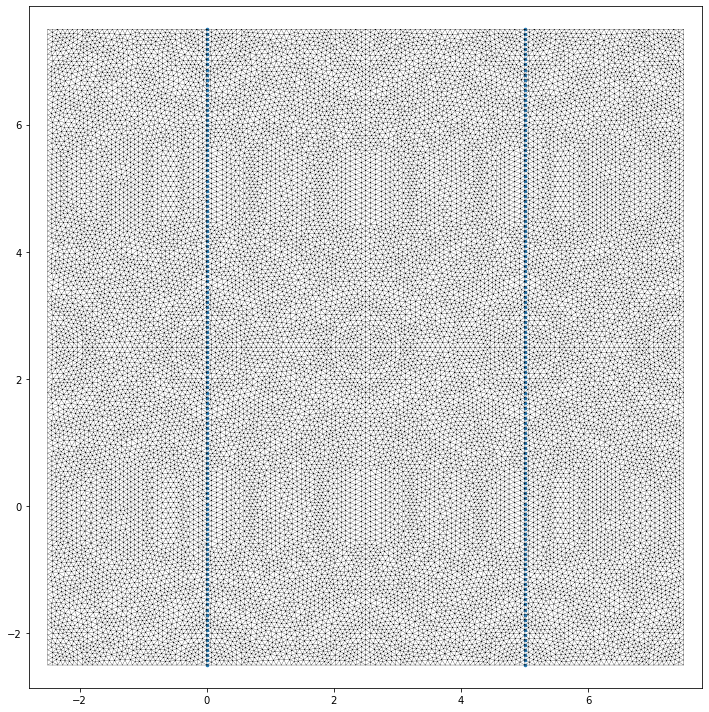

In [13]:
visualization.plot_2d_mesh(m, pointList = fusedVtx, width = 10, height = 10)

In [14]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [15]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [16]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [17]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [18]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [121311, 121312]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.258153	1
    Compress Matrix	0.0833111	2
    InflatablePeriodicUnit.computeAHA	0.0878098	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00600314	1
            baseHessianSparsityPattern	1.90735e-06	1
InflatableSheet setVars	0.000797987	1
Newton iterations	9.75021	1
    InflatableSheet energy	0.00145984	3
    Newton iterate	9.74857	17
        Backtracking	0.124758	16
            InflatableSheet energy	0.0560937	104
            InflatableSheet setVars	0.0286541	36
        Compute descent direction	4.10783	16
            newton_step	4.10778	16
                Catamari Symbolic Factorize	0.287309	1
                    CatamariConverter	0.0221829	1
                    Construct plan	0.010519	1
                        Build	0.0087409	1
                    SparseLDL.Factor	0.0468061	1
                        supernodal_ldl.Factorization.Factor	0.0468009	1
         

In [19]:
cr.success

True

In [20]:
import os

In [21]:
tag = 'parallel_tube'

In [22]:
output_folder = 'selected_patterns/{}/'.format(tag)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [23]:
import parametrization_helper

In [24]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, output_folder, tag, 'selected')

m.save("{}/mesh_{}.obj".format(output_folder, tag))
np.save("{}/fusedVtx_{}.npy".format(output_folder, tag), fusedVtx)

In [ ]:
render = viewer.offscreenRenderer(1000, 1000)
render.render()
render.save("{}/{}_render_{}_{}.png".format(result_folder, '', name, variable))

In [ ]:
name = "isotropy"
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
result_folder = 'output/{}/{}'.format(name, time_stamp)
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  
    
variable = radius

In [ ]:
import importlib, periodic_simulation_setup

In [ ]:
importlib.reload(periodic_simulation_setup)

In [ ]:
points = periodic_simulation_setup.visualize_average_deformation_gradient(ipu, 100, plot_max_r=1, plot_min_r=0, show_figure=True, filename = "{}/average_deformation_gradient_{}_{}.svg".format(result_folder, name, variable))

In [ ]:
az_ipu = get_az_ipu_from_ipu(ipu, m, fusedVtx, useTFT, disableFusedRegionTFT)
if not allowBending:
    fixedVars, hessianShift = [az_ipu.numVars() - 2, az_ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6
opts.niter = 1000
az_optimizer = inflation.get_inflation_optimizer(az_ipu, fixedVars, opts, callback=None, hessianShift = hessianShift)
# cr = az_optimizer.optimize()

In [ ]:
stiffness_shift = 1e-15
success = False
for i in range(15):
    try:
        stiffness_values, sampled_alphas, stiffness_coefficient = periodic_simulation_setup.visualize_sampled_bending_stiffness(az_ipu, 1000, az_optimizer, hessianShift = stiffness_shift, fixedVars = [], filename = "{}/stiffness_{}_{}.svg".format(result_folder, name, variable), show_figure=True, plot_min_r=0)
        np.save("{}/stiffness_values_{}_{}.npy".format(result_folder, name, variable), stiffness_values)
        np.save("{}/sampled_alphas_{}_{}.npy".format(result_folder, name, variable), sampled_alphas)
        np.save("{}/stiffness_coefficient_{}_{}.npy".format(result_folder, name, variable), stiffness_coefficient)
        print("Solved using stiffness shift: ", stiffness_shift)
        success = True
        break
    except:
        print("failed to compute stiffness with shift ", stiffness_shift)
        stiffness_shift *= 10
if (not success):
    print("Failed to solve stiffness!")


In [ ]:
low_pressure_tag = "low_pressure"

In [ ]:
np.save("{}/scale_factors_{}_{}.npy".format(result_folder, name, variable), get_deformation_scale_factors(az_ipu.ipu))
np.save("{}/kappa_{}_{}.npy".format(result_folder, name, variable), az_ipu.getVars()[-2])

np.save("{}/average_deformation_gradient_matrix_{}_{}.npy".format(result_folder, name, variable), get_deformation_matrix(az_ipu.ipu))

np.save("{}/{}_strain_values_{}_{}.npy".format(result_folder, low_pressure_tag, name, variable), utils.getStrains(az_ipu.ipu.sheet)[:, 0])

np.save("{}/{}_dofs_{}_{}.npy".format(result_folder, low_pressure_tag, name, variable), az_ipu.getVars())

In [ ]:
viewer.saveObj("{}/mesh_{}_{}.obj".format(result_folder, name, variable))

In [ ]:
viewer.saveColorizedObj("{}/color_mesh_{}_{}.obj".format(result_folder, name, variable))